# ReachNT: walkthrough

**HMW:** help a housing maintenance coordinator prioritise urgent repairs across remote NT communities without "efficiency" quietly pushing remote tenants to the back of the queue.

This notebook walks the method step by step. It reads the files `run_all.py` writes; run that first (about 10 minutes).

> **Synthetic data.** The individual repair requests are synthetic. The communities, house counts, hubs, road closures, airstrips, job mix, response clocks and cost ratios are real or sourced (see `research/RESEARCH.md`).

In [1]:
import sys, json
sys.path.insert(0, '../src')
import pandas as pd, numpy as np
from reachnt import geo, intake, synth, urgency, planner, explain, simulate
from reachnt.config import OUTPUTS, params, taxonomy
pd.set_option('display.width', 160)
N = json.loads((OUTPUTS / 'numbers.json').read_text())

## 1. Where the houses are

70 remote communities from the 2023 NIAA review of the NT remote housing partnership (house counts estimated from its overcrowding table), matched to NTG coordinates, assigned to the nearest of five crew hubs. Access bands use the Nous (2017) travel thresholds, the NT road-restriction register and an airstrip check.

In [2]:
com = geo.load_communities()
com.groupby(['hub', 'band']).agg(communities=('community', 'count'), houses=('houses_est', 'sum'))

communities  houses
hub           band                                       
Alice Springs Near town (road)                  5     260
              Remote (road)                    13     423
              Remote, cut in the wet            1      33
              Very remote (road)                3     144
Darwin        Island (fly-in)                   5     583
              Near town (road)                  1      41
              Remote, cut in the wet            5     552
Katherine     Near town (road)                  5     218
              Remote, cut in the wet           11     471
Nhulunbuy     Island (fly-in)                   5     602
              Near town (road)                  3     232
              Remote, cut in the wet            3     509
Tennant Creek Remote (road)                     7     221
              Remote, cut in the wet            3     192

## 1b. H3 run zones

Each community gets H3 cells (Uber's hexagonal grid, h3geo.org). Two communities served from the same hub share a trip when their resolution-4 cells (about 1,770 km²) are within two rings.

In [3]:
import h3
pairs = geo.run_pairs(com)
print(len(pairs), 'run-zone pairs')
names = com.set_index('cid').community
pairs.assign(a=pairs.a.map(names), b=pairs.b.map(names)).sort_values('km').head(10).round(1)

68 run-zone pairs


,hub,a,b,grid_distance,km
47,Katherine,DAGURAGU,KALKARINDJI,0,6.4
44,Katherine,RITTARANGU,NGUKURR,1,17.4
8,Alice Springs,PMARA JUTUNTA,NTURIYA,0,19.3
48,Nhulunbuy,GUNYANGARA,YIRRKALA,1,19.8
57,Nhulunbuy,MILINGIMBI,RAMINGINING,1,25.6
37,Katherine,BARUNGA,BESWICK,1,26.0
24,Darwin,MILIKAPITI,PIRLANGIMPI,0,27.3
15,Alice Springs,HAASTS BLUFF,PAPUNYA,1,28.0
34,Katherine,MANYALLALUK,BARUNGA,1,28.1
64,Tennant Creek,ALI CURUNG,IMANGARA,1,28.6


In [4]:
ng = com.set_index('community').loc['NGUKURR']
print('Ngukurr res-7 cell', ng.h3_r7, '| res-4 cell', ng.h3_r4)
print('a synthetic house cell (res 10):', geo.house_cell(ng.cid, 12, (ng.lat, ng.lon), False))
print('res-5 cells within 3 rings:', len(h3.grid_disk(ng.h3_r5, 3)))

Ngukurr res-7 cell 879c4a0d2ffffff | res-4 cell 849c4a1ffffffff
a synthetic house cell (res 10): 8a9c4a0d2b9ffff
res-5 cells within 3 rings: 37


## 2. Reading a fault report

Phrase rules (from `config/taxonomy.yaml`, shared with the web prototype) plus a TF-IDF / logistic regression model. If either is unsure, or the text contains a danger word, a person checks.

In [5]:
tr = synth.labelled_corpus(60, 'train', 1)
clf = intake.Classifier().fit(tr.text, tr.hazard)
for t in ['power point is sparking and the baby sleeps there',
          'nothing comes out of the taps',
          'black marks and melting on the power point',
          'cockroaches everywhere',
          'pls come']:
    r = intake.read(t, clf)
    print(f'{t!r:55} -> {r.hazard:18} person={r.needs_human}  {r.reasons[:1]}')

'power point is sparking and the baby sleeps there'     -> electrical_danger  person=False  ['Immediate jobs are confirmed by phone and made safe by the local Housing Maintenance Officer.']
'nothing comes out of the taps'                         -> electrical_danger  person=True  ['We could not read this report with confidence. A person will call back.']
'black marks and melting on the power point'            -> power_point        person=True  ['This might be dangerous. A person will call to check today.']
'cockroaches everywhere'                                -> pests              person=False  []
'pls come'                                              -> stove_broken       person=True  ['We could not read this report with confidence. A person will call back.']


### How well does it read wording it has never seen?

The test set uses phrasings kept out of training. Accuracy drops on new wording, so the safety net (send to a person) matters more than the model.

In [6]:
pd.DataFrame({(s, k): v for s in ['seen', 'heldout'] for k, v in N['reader'][s].items() if k != 'n'}).T.round(3)

hazard_acc  category_acc  under_triaged  under_triaged_unflagged  danger_missed  to_person
seen    rules          0.770         0.836          0.076                      NaN            NaN        NaN
        model          0.955         0.964          0.018                      NaN            NaN        NaN
        combined       0.852         0.903          0.009                    0.006          0.000      0.167
heldout rules          0.526         0.624          0.326                      NaN            NaN        NaN
        model          0.421         0.592          0.223                      NaN            NaN        NaN
        combined       0.689         0.786          0.109                    0.032          0.013      0.397

## 3. Need-only urgency

The score's inputs are the fault, what the report says about who lives there, and days waited. Distance, cost, community and region are not inputs (a test enforces this).

In [7]:
for hz, mods in [('electrical_danger', {}), ('hot_water', {'vulnerable': 1}), ('toilet_blocked', {}), ('pests', {})]:
    print(hz, urgency.score(hz, mods).parts())
print('Clocks (calendar days): equal urgent', urgency.clock_days('urgent', True, 'equal'),
      '| official remote urgent', urgency.clock_days('urgent', True, 'official'),
      '| official town urgent', urgency.clock_days('urgent', False, 'official'))

electrical_danger {'category': 'immediate', 'base': 1000, 'harm': 95, 'hlp': 40, 'exposure': 0, 'repeat': 0, 'ageing': 0, 'total': 1135}
hot_water {'category': 'urgent', 'base': 500, 'harm': 55, 'hlp': 36, 'exposure': 25, 'repeat': 0, 'ageing': 0, 'total': 616}
toilet_blocked {'category': 'urgent', 'base': 500, 'harm': 55, 'hlp': 28, 'exposure': 0, 'repeat': 0, 'ageing': 0, 'total': 583}
pests {'category': 'routine', 'base': 100, 'harm': 25, 'hlp': 16, 'exposure': 0, 'repeat': 0, 'ageing': 0, 'total': 141}
Clocks (calendar days): equal urgent 2.8 | official remote urgent 7.0 | official town urgent 2.8


## 4. Why town always looks cheaper

One job sent alone to a very remote community is almost all travel, matching Nous (2017): "up to 96 per cent". Batch ten jobs and the share falls.

In [8]:
pd.DataFrame(N['calibration']).T.round(2)

,mode,one_job_total,one_job_travel_share,ten_jobs_travel_share,per_job_ten
Kintore,road,3911.433699,0.91691,0.565301,747.64337
Lajamanu,road,3488.456277,0.906836,0.539233,705.345628
Wadeye,road,2377.16986,0.863283,0.453062,594.216986
Galiwinku,air,4784.173402,0.932068,0.61074,834.91734
Barunga,road,792.735667,0.590027,0.125812,371.773567


## 5. One year under each setting

The weekly planner (OR-Tools CP-SAT) chooses trips per hub and trade. Settings differ only in how each job is valued and how much travel cost counts (λ, points per dollar).

In [9]:
P = pd.DataFrame([{k: v for k, v in s.items() if k != 'bands'} for s in N['policies'].values()])
P[['key', 'label', 'cost_per_job', 'total_cost', 'urgent_p90_town', 'urgent_p90_remote', 'overdue_equal_remote', 'harm_days_total', 'air_trips']].round(2)

,key,label,cost_per_job,total_cost,urgent_p90_town,urgent_p90_remote,overdue_equal_remote,harm_days_total,air_trips
0,cheapest_1,Cheapest jobs first,557.51,20485701.16,3.0,62.0,0.59,215974.90,599
1,floor_1,Cheapest first + urgent guarantee,727.36,27024159.47,3.0,7.0,0.30,88699.42,1389
2,official_0.2,"Need first, official remote allowance",731.58,27429892.75,3.0,13.0,0.35,78933.10,1381
3,guarantee_0.2,Need first + urgent guarantee (ReachNT default),843.01,31579103.77,3.0,3.0,0.29,75786.20,1878
4,guarantee_0.5,"Need first + urgent guarantee, tighter budget",776.83,29014439.09,3.0,6.0,0.28,95040.20,1597
5,guarantee_0.2_h3,ReachNT: need first + urgent guarantee + H3 ru...,775.04,29048524.06,3.0,3.0,0.26,61688.78,2202
6,guarantee_0.5_h3,"ReachNT, tighter budget (H3 run zones)",720.50,26962707.13,3.0,3.0,0.26,78487.62,1878
7,cheapest_1_h3,Cheapest jobs first + H3 run zones,553.65,20506525.97,3.0,38.0,0.53,170556.60,913
8,need_0.8,"Need first, cost-aware (lam 0.8)",564.19,20950164.22,3.0,34.0,0.53,154927.45,620
9,need_0.4,Need first (lam 0.4),691.32,25880202.83,3.0,16.0,0.40,86137.58,1183


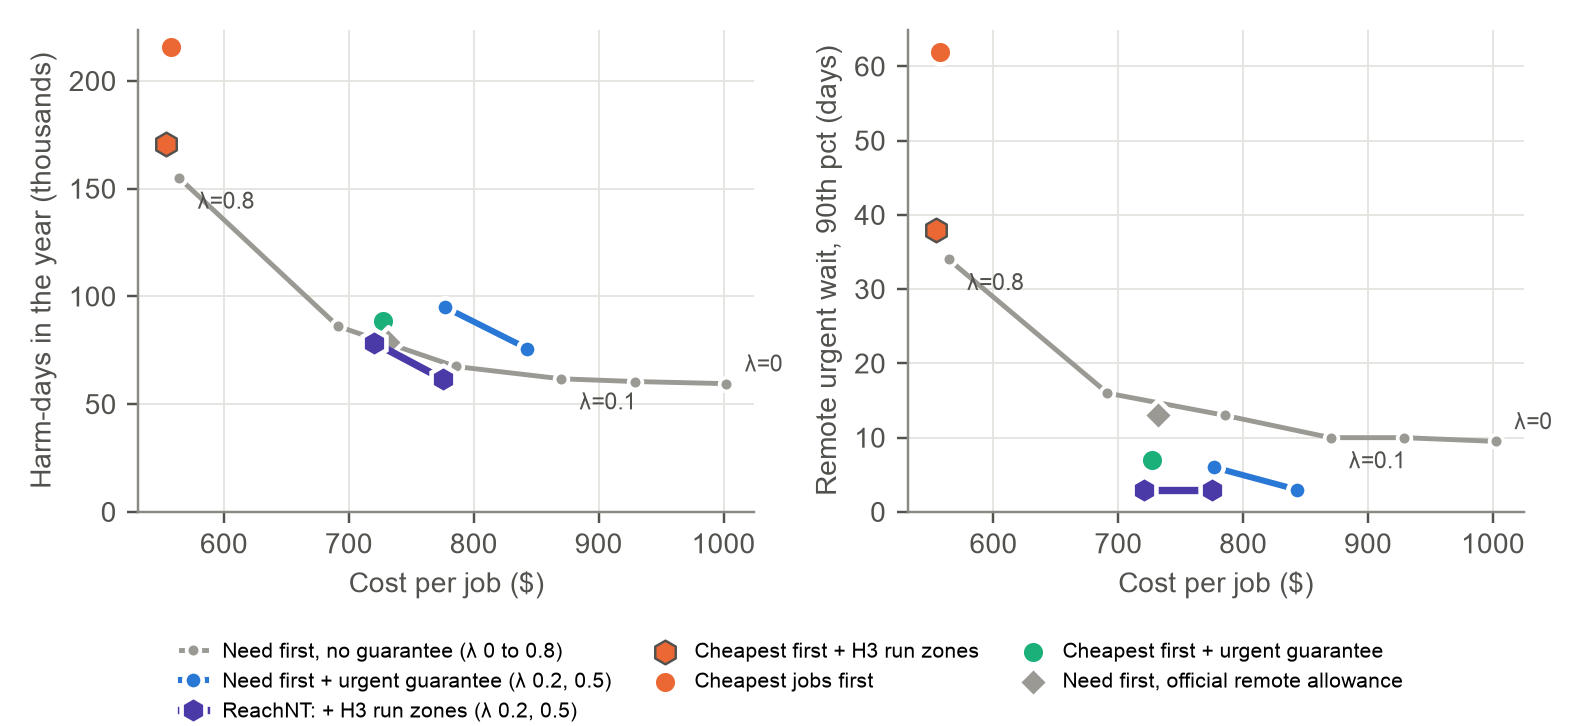

In [10]:
from IPython.display import Image
Image(filename=str(OUTPUTS / 'figures' / 'fig2_frontier.png'))

In [11]:
B = pd.read_csv(OUTPUTS / 'bands.csv')
B[B.key.isin(['cheapest_1', 'guarantee_0.2', 'guarantee_0.2_h3'])].pivot(index='band', columns='key', values='urgent_p90').round(0)

key,cheapest_1,guarantee_0.2,guarantee_0.2_h3
band,,,
Island (fly-in),71.0,3.0,3.0
Near town (road),3.0,3.0,3.0
Remote (road),58.0,13.0,8.0
"Remote, cut in the wet",79.0,7.0,3.0
Town,3.0,3.0,3.0
Very remote (road),69.0,20.0,15.0


## 6. Does the answer survive the assumptions?

Crew capacity, the wet-season cut share, the charter rate and a second random year, changed one at a time.

In [12]:
S = pd.DataFrame(N['sensitivity'])
S.pivot_table(index=['param', 'value'], columns='policy', values=['cost_per_job', 'urgent_p90_remote']).round(0) if len(S) else 'run python run_all.py (without --quick) for the sweep'

cost_per_job           urgent_p90_remote          
policy                         cheapest guarantee          cheapest guarantee
param              value                                                     
capacity_factor    1.15           541.0     799.0              77.0       6.0
                   1.50           566.0     839.0              56.0       3.0
charter_per_hour   1500.00        564.0     739.0              41.0       6.0
                   3000.00        559.0     879.0              72.0       6.0
random_year        99.00          566.0     814.0              41.0       4.0
wet_cut_week_share 0.20           558.0     835.0              62.0       3.0
                   0.50           565.0     830.0              56.0       3.0

## 7. What a tenant is told

Built from the job's weekly reason log and the signed decision record.

In [13]:
jobs = pd.read_parquet(OUTPUTS / 'jobs_cheapest_1.parquet').merge(pd.read_parquet(OUTPUTS / 'reasons_cheapest_1.parquet'), on='job_id')
j = jobs[(~jobs.town) & (jobs.category == 'urgent')].sort_values('wait_days').iloc[-50].to_dict()
j['reason_log'] = json.loads(j['reason_log'])
place = com.set_index('cid').loc[j['site'], 'community'].title()
ex = explain.tenant_explanation(j, place, dict(policy='cheapest', role='coordinator', date='(no decision recorded)'),
                                com.set_index('cid').loc[j['site']].to_dict())
print(ex['short'], '\n')
for t, b in ex['sections']:
    print(t.upper()); print(b, '\n')

Your roof leak or storm damage repair is urgent. Waiting 243 days. Held up by travel cost. Ask why: 1800 104 076 

WHAT WE HEARD
You told us: "STORM LIFTED THE ROOF SHEETS, MY HUSBAND IS ON DIALYSIS". We read this as: roof leak or storm damage. 

HOW URGENT IT IS
This is an Urgent repair. Our rule is the same in town and out bush: a carpenter within 2 business days. The law calls this kind of fault an emergency repair. 

WHERE IT IS UP TO
Not fixed yet. You have waited 243 days. That is longer than our rule, by 240 days. 

WHY IT IS NOT FIXED YET
For 133 days no carpenter was sent to Robinson River. It costs about $13,300 to fly one there and back. That was a cost decision, not a judgement about your repair. Nobody signed off on it. For 98 days every carpenter was fully booked on repairs that scored higher than yours. Higher scores mean more danger or a longer wait. For 14 days a carpenter was working nearby but did higher-scoring repairs first. 

WHAT WOULD CHANGE IT
If it gets worse 